# 00 · Gesamtüberblick QUA³CK

Vom prüfbaren Problem zur transparenten Machine-Learning-App.

**Projekt:** MietCheck · Data Analytics & Big Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## Forschungsfrage und Produktidee

**Forschungsfrage:** Wie stark weichen aktuelle Angebotsmieten von lokal erwartbaren Bestandsmieten ab, und wie verändert dieser Abstand die persönliche Mietbelastung?

MietCheck trennt drei Größen, die andere Rechner häufig vermischen:

1. modellierte lokale Zensus-Bestandsmiete (Stichtag 15.05.2022),
2. aktuelle GREIX-Angebotsmiete (Q1/2026),
3. persönliche Miete beziehungsweise Budget.

Der daraus berechnete **Umzugsaufschlag** ist das Alleinstellungsmerkmal. Er wird mit Datenstand, Marktstreuung, Modellunsicherheit und Grenzen ausgegeben.

In [2]:
build = load_json("reports/dataset_build_report.json")
greix = load_json("data/app/greix_metadata.json")
benchmark = load_json("reports/algorithm_benchmark.json")
final = load_json("reports/final_model_evaluation.json")

kpis = pd.DataFrame([
    ("Zensus-Zielzeilen", f"{build['rows']:,}"),
    ("100-m-Gitterzellen", f"{build['unique_grid_cells']:,}"),
    ("GREIX-Regionen", greix["regions"]),
    ("Aktueller Datenstand", greix["latest_period"]),
    ("verglichene Modellfamilien", len(benchmark["models"])),
    ("finaler räumlicher Test-MAE", f"{final['test']['point_metrics']['mae']:.3f} €/m²"),
    ("empirische Intervall-Coverage", f"{final['test']['category_specific_90_percent_interval']['coverage']:.1%}"),
], columns=["Nachweis", "Wert"])
display(kpis.style.hide(axis="index"))

Nachweis,Wert
Zensus-Zielzeilen,"2,058,569"
100-m-Gitterzellen,"1,184,386"
GREIX-Regionen,38
Aktueller Datenstand,2026-Q1
verglichene Modellfamilien,5
finaler räumlicher Test-MAE,1.413 €/m²
empirische Intervall-Coverage,86.8%


In [3]:
profiles = pd.read_csv(ROOT / "data/app/region_profiles.csv")
snapshot = pd.DataFrame({
    "Kennzahl": ["lokale GREIX-Märkte", "Angebotsmedian min.", "Angebotsmedian max.",
                 "Zensus-Referenz", "GREIX-Referenz"],
    "Wert": [len(profiles), f"{profiles['asking_median_eur_sqm'].min():.2f} €/m²",
             f"{profiles['asking_median_eur_sqm'].max():.2f} €/m²",
             "15.05.2022", profiles['period'].max()],
})
display(snapshot.style.hide(axis="index"))

Kennzahl,Wert
lokale GREIX-Märkte,37
Angebotsmedian min.,6.00 €/m²
Angebotsmedian max.,23.00 €/m²
Zensus-Referenz,15.05.2022
GREIX-Referenz,2026-Q1


## QUA³CK-Nachweiskette

| Phase | Leitfrage | Notebook / Evidenz |
|---|---|---|
| Q · Question | Welches Problem, für wen und mit welchen KPIs? | `01_question.ipynb` |
| U · Understanding | Sind Quellen belastbar und wie verteilen sich Ziel und Merkmale? | `02_understanding_the_data.ipynb` |
| A¹ · Auswahl | Welche Modellfamilie generalisiert räumlich? | `03_algorithmenauswahl.ipynb` |
| A² · Adapting | Welche Feature-Gruppen liefern Zusatznutzen? | `04_modellentwicklung.ipynb` |
| A³ · Adjusting | Welche Hyperparameter generalisieren stabil? | `04_modellentwicklung.ipynb` |
| C · Comparing | Wie gut ist es auf gesperrten Regionen? | `05_kreuzvalidierung.ipynb` |
| K · Knowledge | Welcher Mehrwert entsteht für Mietende? | `06_wissensextraktion.ipynb` |

,model,mean_mae,std_mae,improvement_vs_baseline_pct
0,hist_gradient_boosting,1.305,0.055,24.118
1,random_forest,1.320,0.053,23.207
2,mlp,1.397,0.076,18.760
3,ridge,1.632,0.105,5.056
4,category_median,1.719,0.125,0.000


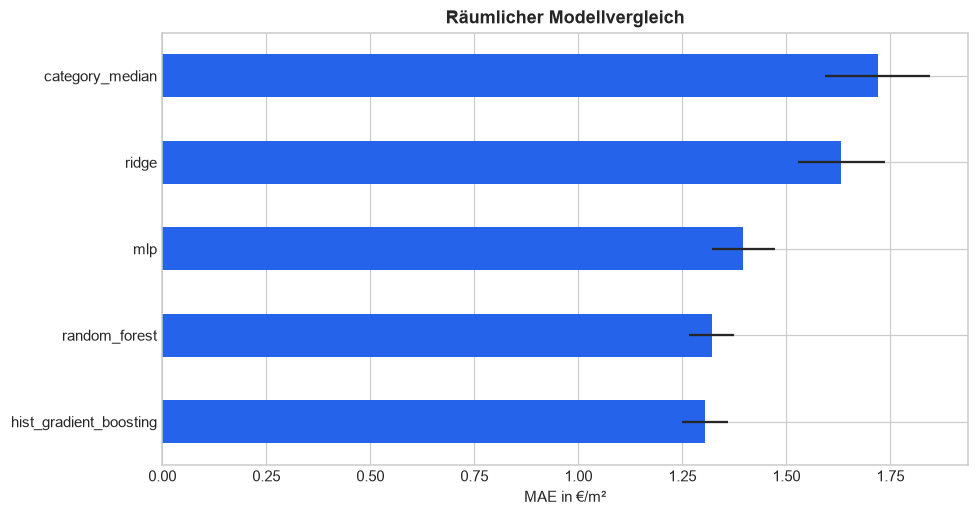

In [4]:
models = pd.DataFrame(benchmark["ranking_by_mean_mae"])
models["improvement_vs_baseline_pct"] = (
    1 - models["mean_mae"] / models.loc[models["model"].eq("category_median"), "mean_mae"].iloc[0]
) * 100
display(models.round(3))

ax = models.sort_values("mean_mae").plot.barh(
    x="model", y="mean_mae", xerr="std_mae", color=COLORS["blue"], legend=False
)
ax.set(title="Räumlicher Modellvergleich", xlabel="MAE in €/m²", ylabel="")
plt.tight_layout(); plt.show()

## Vorab definierte Erfolgskriterien

- mindestens 2 Mio. Beobachtungen und reproduzierbarer Download,
- mindestens vier Modellfamilien plus fachliche Baseline,
- keine räumliche Überschneidung zwischen Trainings-, Kalibrierungs- und Testblöcken,
- mindestens 15 % MAE-Verbesserung gegenüber der Kategorien-Baseline,
- sichtbare Unsicherheit ohne falsche Garantie,
- aktueller Marktstand und Quellen direkt am Ergebnis,
- Streamlit-App, GitHub, Tests, Modellkarte, Präsentation und Handout.

---

**Reproduzierbarkeit:** Die visualisierten Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die jeweils genannten Skripte erzeugen diese Artefakte aus den öffentlichen Rohdaten erneut. Relative Pfade funktionieren sowohl aus der Projektwurzel als auch aus `notebooks/`.